# Modes Mobility Coupling near wall

## Libraries and dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import particles_mod.Icosphere as ico
import libMobility as lm
import pyvista as pv
pv.set_jupyter_backend('html')



   ██╗   ██╗██╗     ███╗   ███╗██████╗
   ██║   ██║██║     ████╗ ████║██╔══██╗
   ██║   ██║██║     ██╔████╔██║██████╔╝
   ╚██╗ ██╔╝██║     ██║╚██╔╝██║██╔═══╝
    ╚████╔╝ ███████╗██║ ╚═╝ ██║██║
     ╚═══╝  ╚══════╝╚═╝     ╚═╝╚═╝
    VIRTUAL   LAB    MODELING  PLATFORM




09/07/2025 09:30:42 - VLMP - INFO - Starting VLMP... 
09/07/2025 09:30:43 - VLMP - ERROR - No module named 'orthopoly' (__init__.py:187)
09/07/2025 09:30:43 - VLMP - ERROR - [Model] Error importing model type component CORONAVIRUS (__init__.py:188)
09/07/2025 09:30:43 - VLMP - ERROR - No module named 'Bio' (__init__.py:187)
09/07/2025 09:30:43 - VLMP - ERROR - [Model] Error importing model type component ENM (__init__.py:188)
09/07/2025 09:30:43 - VLMP - ERROR - No module named 'pyquaternion' (__init__.py:187)
09/07/2025 09:30:43 - VLMP - ERROR - [Model] Error importing model type component HELIX (__init__.py:188)
09/07/2025 09:30:43 - VLMP - ERROR - No module named 'Bio' (__init__.py:187)
09/07/2025 09:30:43 - VLMP - ERROR - [Model] Error importing model type component IDP (__init__.py:188)
09/07/2025 09:30:43 - VLMP - ERROR - No module named 'Bio' (__init__.py:187)
09/07/2025 09:30:43 - VLMP - ERROR - [Model] Error importing model type component KB (__init__.py:188)
09/07/2025 09:30:

## Functions

In [2]:
def create_solver(positions: np.ndarray, wallHeight: float = 0.0,
                  hydrodynamicRadius: float = 1.0, viscosity: float = 1/(6 * np.pi)):
    """
    Create a libmobility solver based on the NBodywall mobility.
    Args:
        positions: The positions of the particles.
        wallHeight: Height of the wall for the NBodywall model. Default is 0.0.
    Returns:
        solver: An instance of the solver for the specified model.
    """

    solver = lm.NBody("open", "open", "single_wall")
    solver.setParameters(wallHeight = wallHeight)

    solver.initialize(
        temperature=0.0,
        viscosity=viscosity,
        hydrodynamicRadius=hydrodynamicRadius,
    )

    solver.setPositions(positions)
    return solver

def plot_mode(positions : list, eigenmode: np.ndarray):
    """
    Plot the eigenmode of the Hessian matrix.
    :param positions: A list of tuples containing the x, y and z coordinates of each particle.
    :param eigenvectors: A numpy array containing the eigenmode data in (nparticles, 3) format.
    :param mode: The index of the eigenmode to plot.
    """

    new_positions = np.array(positions) + np.array(eigenmode)   # Scale the eigenmode for visualization

    mesh = pv.PolyData(new_positions)
    mesh = mesh.delaunay_3d()
    mesh['Eigenvector'] = eigenmode  # Add the eigenmode as a scalar field for coloring
    p = pv.Plotter()
    p.add_mesh(mesh, scalars='Eigenvector', show_scalar_bar=True, show_edges=False, cmap='coolwarm')
    p.add_arrows(np.array(positions), eigenmode / np.max(np.linalg.norm(eigenmode, axis=1))*3, color='blue', opacity=0.95
                 , name='Eigenvector Arrows')
    p.window_size = [300, 250]
    # add the coordinate triad bigger
    p.add_axes(interactive=True, line_width=5, labels_off=False, color='black')
    p.show()

## Creating icosphere and modes

In [3]:
num_particles = 300
density = 1/(np.pi * 1.05**2) # Closed package distribution
radius = np.sqrt(num_particles / (density * 4.0 * np.pi))

icosphere = ico.IcoSphere(radius=radius, density=density, Kpair=5, Kdi=5)


Creating icosphere with 300 particles and frequency division 5
Icosphere created with normalized positions and faces.
Number of particles: 252
Generating VLMP data for the icosphere.


09/07/2025 09:30:43 - VLMP - INFO - [VLMP] Starting VLMP 
09/07/2025 09:30:43 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
09/07/2025 09:30:43 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
09/07/2025 09:30:43 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
09/07/2025 09:30:43 - VLMP - DEBUG - [VLMP] (system) Component parameters "{'simulationName': 'Icosphere'}" (VLMP.py:207)
09/07/2025 09:30:43 - VLMP - DEBUG - [VLMP] Processing "system" component ({'type': 'simulationName', 'parameters': {'simulationName': 'Icosphere'}}), type "simulationName" (VLMP.py:194)
09/07/2025 09:30:43 - VLMP - WARNING - [VLMP] (system) Component name not specified, using "simulationName". 
09/07/2025 09:30:43 - VLMP - DEBUG - [VLMP] (system) Component name "simulationName". (VLMP.py:200)
09/07/2025 09:30:43 - VLMP

VLMP data generated.


In [4]:

icosphere.obtain_modes()
icosphere.modes = ico.reconstruct_modes(modes=icosphere.modes, positions=icosphere.positions)





Preliminary simulation structure created


[WARNING] UAMMD-structured Python wrapper is not compatible with UAMMD-structured self restarting mechanism


Read Hessian file /tmp/tmpyg34c725/hessian.txt with shape (63504, 11)


[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: May 30 2025 09:48:24
[MESSAGE] Compiled in double precision mode
[MESSAGE] Computation started at Wed Jul  9 09:30:44 2025

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 3080 with id: 0
[MESSAGE] [System] Compute capability of the device: 8.6
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [ExtendedSystem] (system) Name: Icosphere
[MESSAGE] [ExtendedSystem] (system) Seed: 1752046244475938554
[MESSAGE] [GlobalDataBase] Fundamental not specified, using default fundamental, "Time"
[WARNING] [Time] No timeStep specified, using 0.0 as default.
[MESSAGE] [Basic] Loaded type A, mass: 1.000000, radius: 0.500000, charge: 0.000000
[MESSAGE] [ParticleData] Created with 252 particles.
[MESSAGE] [StateLoader] Loading property "id".
[MESSAGE] [S

In [5]:

height = 2  # Wall height for the NBodywall model
solver = create_solver(icosphere.positions, wallHeight=-radius - height - 1.0)
coupling_matrix = icosphere.obtain_normal_coupled_mobility(solver)

In [6]:
N_matrix = coupling_matrix[6:,6:]
N_inverse = np.linalg.pinv(N_matrix)

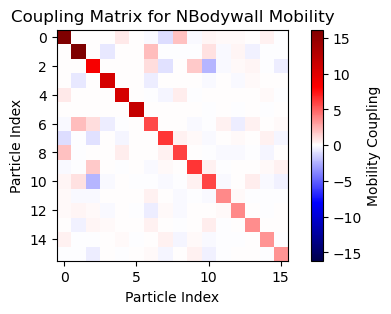

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
n = 16
ax.imshow(coupling_matrix[:n,:n])
ax.set_title("Coupling Matrix for NBodywall Mobility")
ax.set_xlabel("Particle Index")
ax.set_ylabel("Particle Index")
# add a colorbar from maximum and negative maximum as the range
max_value = np.max(np.abs(coupling_matrix[:n,:n]))
cbar = plt.colorbar(ax.imshow(coupling_matrix[:n,:n], aspect='equal', vmin=-max_value, vmax=max_value, cmap='seismic'), ax=ax)
cbar.set_label("Mobility Coupling")
plt.show()

In [8]:
for mode in range(6):
    plot_mode(icosphere.positions, icosphere.modes[:, mode].reshape(icosphere.nparticles, 3))

2025-07-09 09:30:46.774 (   3.391s) [    7F745C6535C0]      vtkDelaunay3D.cxx:513   WARN| vtkDelaunay3D (0x55da209b8470): 1 degenerate triangles encountered, mesh quality suspect
2025-07-09 09:30:46.778 (   3.395s) [    7F745C6535C0]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

2025-07-09 09:30:46.987 (   3.604s) [    7F745C6535C0]      vtkDelaunay3D.cxx:513   WARN| vtkDelaunay3D (0x55da22c4e300): 1 degenerate triangles encountered, mesh quality suspect


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

2025-07-09 09:30:47.080 (   3.697s) [    7F745C6535C0]      vtkDelaunay3D.cxx:513   WARN| vtkDelaunay3D (0x55da23750af0): 1 degenerate triangles encountered, mesh quality suspect


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

2025-07-09 09:30:47.377 (   3.994s) [    7F745C6535C0]      vtkDelaunay3D.cxx:513   WARN| vtkDelaunay3D (0x55da255f18a0): 2 degenerate triangles encountered, mesh quality suspect


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [9]:

deformation_modes = N_inverse @ coupling_matrix[6:,0]/icosphere.eigenvalues[6:]

In [10]:
plot_mode(icosphere.positions, (icosphere.modes[:, 6:] @ deformation_modes).reshape(icosphere.nparticles, 3))

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

In [11]:
import logging
# shut up debug for everything
logging.getLogger("VLMP").setLevel(logging.ERROR)
logging.getLogger("pyUAMMD").setLevel(logging.ERROR)

In [ ]:

# distance dependence of tt_eff_mobility

sphere_radius = np.linspace(4, 12, 15)
density = 1/(np.pi * 1.05**2)  # Closed package distribution
num_distances = 30
limit_diameter = 10  # Limit for the distance to the wall in terms of the sphere diameter

tt_eff_mobility = np.zeros((len(sphere_radius), num_distances))
rt_eff_mobility = np.zeros((len(sphere_radius), num_distances))
for j, radius in enumerate(sphere_radius):
    print(f"Calculating for radius {radius:.2f}")
    icosphere = ico.IcoSphere(radius=radius, density=density, Kpair=2, Kdi=2)
    logging.info("Obtaining modes for the icosphere.")
    icosphere.obtain_modes()
    logging.info("Reconstructing modes based on positions.")
    icosphere.modes = ico.reconstruct_modes(modes=icosphere.modes, positions=icosphere.positions)
    distances = np.logspace(-1, np.log10(limit_diameter*2*radius), num_distances)
    for i, distance in enumerate(distances):
        logging.info(f"Creating solver for distance {distance:.2f} and radius {radius:.2f}.")
        solver = create_solver(icosphere.positions, wallHeight=-radius - distance)
        logging.info("Obtaining normal coupled mobility matrix.")
        coupling_matrix = icosphere.obtain_normal_coupled_mobility(solver)
        N_matrix = coupling_matrix[6:,6:]
        logging.info("Calculating the inverse of the N matrix.")
        N_inverse = np.linalg.pinv(N_matrix)

        normalized_displacements = N_inverse @ coupling_matrix[6:,0]

        tt_coupling = coupling_matrix[0,0] - coupling_matrix[0,6:] @ normalized_displacements
        rt_coupling = coupling_matrix[4,0] - coupling_matrix[4,6:] @ normalized_displacements

        linear_force = 1.0 
        linear_force_coeff = linear_force * icosphere.modes[0,0]

        rotational_velocity = np.linalg.norm(icosphere.modes[0,:3]) / radius

        tt_velocity_coeff = tt_coupling * linear_force_coeff
        rt_velocity_coeff = rt_coupling * linear_force_coeff

        tt_velocity = tt_velocity_coeff * icosphere.modes[0,0]
        rt_velocity = np.linalg.norm(rt_velocity_coeff * icosphere.modes[0,:3]) / radius

        tt_eff_mobility[j, i] = tt_velocity / linear_force
        rt_eff_mobility[j, i] = rt_velocity / linear_force

print("Calculation complete.")


Calculating for radius 12.00
Creating icosphere with 522 particles and frequency division 7
Icosphere created with normalized positions and faces.
Number of particles: 492
Generating VLMP data for the icosphere.


09/07/2025 09:43:07 - pyUAMMD - DEBUG - Initializing simulation, ID: 5ac9dfc45c9811f0a307ac1f6bd9c368 (simulation.py:72)
DEBUG:pyUAMMD:Initializing simulation, ID: 5ac9dfc45c9811f0a307ac1f6bd9c368
09/07/2025 09:43:07 - pyUAMMD - DEBUG - Simulation created (simulation.py:107)
DEBUG:pyUAMMD:Simulation created
09/07/2025 09:43:07 - pyUAMMD - DEBUG - Initializing simulation, ID: 5acac2d65c9811f0a307ac1f6bd9c368 (simulation.py:72)
DEBUG:pyUAMMD:Initializing simulation, ID: 5acac2d65c9811f0a307ac1f6bd9c368
09/07/2025 09:43:07 - pyUAMMD - DEBUG - Simulation created (simulation.py:107)
DEBUG:pyUAMMD:Simulation created
09/07/2025 09:43:07 - pyUAMMD - DEBUG - Appending "5acac2d65c9811f0a307ac1f6bd9c368" to "5ac9dfc45c9811f0a307ac1f6bd9c368" with mode "modelId" (simulation.py:128)
DEBUG:pyUAMMD:Appending "5acac2d65c9811f0a307ac1f6bd9c368" to "5ac9dfc45c9811f0a307ac1f6bd9c368" with mode "modelId"
09/07/2025 09:43:07 - pyUAMMD - DEBUG - Initializing simulation, ID: 5acbccc65c9811f0a307ac1f6bd9c368 

VLMP data generated.
Preliminary simulation structure created


[WARNING] UAMMD-structured Python wrapper is not compatible with UAMMD-structured self restarting mechanism
[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: May 30 2025 09:48:24
[MESSAGE] Compiled in double precision mode
[MESSAGE] Computation started at Wed Jul  9 09:43:07 2025

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 3080 with id: 0
[MESSAGE] [System] Compute capability of the device: 8.6
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [

Read Hessian file /tmp/tmpwjbgtg0q/hessian.txt with shape (242064, 11)


...

Calculating for radius 11.43
Creating icosphere with 474 particles and frequency division 7
Icosphere created with normalized positions and faces.
Number of particles: 492
Generating VLMP data for the icosphere.


09/07/2025 09:43:51 - pyUAMMD - DEBUG - Initializing simulation, ID: 7529add65c9811f0a307ac1f6bd9c368 (simulation.py:72)
DEBUG:pyUAMMD:Initializing simulation, ID: 7529add65c9811f0a307ac1f6bd9c368
09/07/2025 09:43:51 - pyUAMMD - DEBUG - Simulation created (simulation.py:107)
DEBUG:pyUAMMD:Simulation created
09/07/2025 09:43:51 - pyUAMMD - DEBUG - Initializing simulation, ID: 752a7ea05c9811f0a307ac1f6bd9c368 (simulation.py:72)
DEBUG:pyUAMMD:Initializing simulation, ID: 752a7ea05c9811f0a307ac1f6bd9c368
09/07/2025 09:43:51 - pyUAMMD - DEBUG - Simulation created (simulation.py:107)
DEBUG:pyUAMMD:Simulation created
09/07/2025 09:43:51 - pyUAMMD - DEBUG - Appending "752a7ea05c9811f0a307ac1f6bd9c368" to "7529add65c9811f0a307ac1f6bd9c368" with mode "modelId" (simulation.py:128)
DEBUG:pyUAMMD:Appending "752a7ea05c9811f0a307ac1f6bd9c368" to "7529add65c9811f0a307ac1f6bd9c368" with mode "modelId"
09/07/2025 09:43:51 - pyUAMMD - DEBUG - Initializing simulation, ID: 752b823c5c9811f0a307ac1f6bd9c368 

VLMP data generated.
Preliminary simulation structure created


[WARNING] UAMMD-structured Python wrapper is not compatible with UAMMD-structured self restarting mechanism
[MESSAGE] ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
[MESSAGE] ╻ ╻┏━┓┏┳┓┏┳┓╺┳┓
[MESSAGE] ┃ ┃┣━┫┃┃┃┃┃┃ ┃┃ Version: 2.5
[MESSAGE] ┗━┛╹ ╹╹ ╹╹ ╹╺┻┛
[MESSAGE] Compiled at: May 30 2025 09:48:24
[MESSAGE] Compiled in double precision mode
[MESSAGE] Computation started at Wed Jul  9 09:43:52 2025

[MESSAGE] [System] CUDA initialized
[MESSAGE] [System] Using device: NVIDIA GeForce RTX 3080 with id: 0
[MESSAGE] [System] Compute capability of the device: 8.6
[MESSAGE] ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ ━ 
[MESSAGE] [ExtendedSystem] (system) Name: Icosphere
[MESSAGE] [ExtendedSystem] (system) Seed: 1752047032139510521
[MESSAGE] [GlobalDataBase] Fundamental not specified, using default fundamental, "Time"
[WARNING] [Time] No timeStep specified, using 0.0 as default.
[MESSAGE] [Basic] Loaded type A, mass: 1.000000, radius: 0.500000, charge: 0.000000
[MES

Read Hessian file /tmp/tmpag5rx0sn/hessian.txt with shape (242064, 11)


<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3828189/1082347469.py:35: SyntaxWarning: invalid escape sequence '\m'
  plt.plot([], [], color='black', label='$\mathcal{M}_{tt}^{eff}$')
/tmp/ipykernel_3828189/1082347469.py:36: SyntaxWarning: invalid escape sequence '\m'
  plt.plot([], [], linestyle=':', color='black', label='$\mathcal{M}_{rt}^{eff}$')


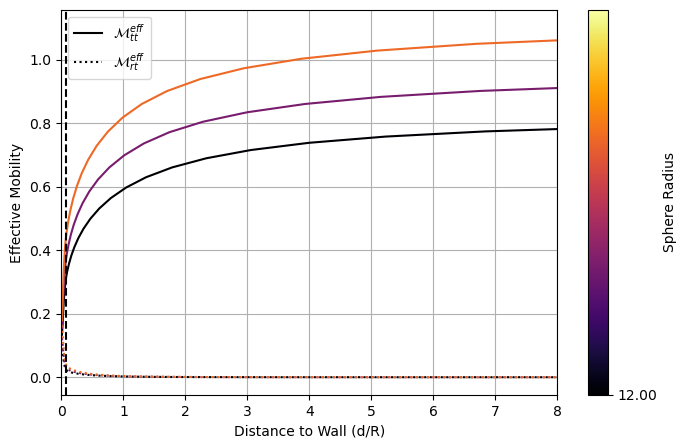

In [21]:

# add a colorbar for the sphere radii

plt.figure(figsize=(8, 5))
palette = 'inferno'
import matplotlib
color_map = matplotlib.colormaps[palette] 

for i, radius in enumerate(sphere_radius):
    distances = np.logspace(-1, np.log10(limit_diameter*2*radius), num_distances)
    plt.plot(distances/radius, tt_eff_mobility[i,:] * radius, color=color_map(i/len(sphere_radius)))
    plt.plot(distances/radius, rt_eff_mobility[i,:] * radius**2, linestyle=':', color=color_map(i/len(sphere_radius)))

# add a vertical line at 1.0/mean_radius
mean_radius = np.mean(sphere_radius)
plt.axvline(x=1.0/mean_radius, color='black', linestyle='--')


cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=palette), ax=plt.gca())
cbar.set_label('Sphere Radius')
num_ticks = np.min([5, len(sphere_radius)//2])
cbar.set_ticks(np.linspace(0, 1, num_ticks))
cbar.set_ticklabels([f'{r:.2f}' for r in sphere_radius[np.linspace(0, len(sphere_radius)-1, num_ticks, dtype=int)]])


plt.xlabel('Distance to Wall (d/R)')
plt.ylabel('Effective Mobility')
#plt.xscale('log')
#plt.yscale('log')

plt.grid()

#plt.ylim(1e-3, 1.4)
plt.xlim(0, 8.0)
#plt.gca().set_aspect('equal', adjustable='box')
plt.plot([], [], color='black', label='$\mathcal{M}_{tt}^{eff}$')
plt.plot([], [], linestyle=':', color='black', label='$\mathcal{M}_{rt}^{eff}$')
plt.legend()
plt.show()